In [12]:
import os
os.chdir("/Users/edwardcaraballo/DA Comp 2026")
print(os.getcwd())
print(os.listdir())

/Users/edwardcaraballo/DA Comp 2026
['.DS_Store', '.ipynb_checkpoints', 'Q2', 'Q3']


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
excel_file = pd.ExcelFile("2025 County Health Rankings Data.xlsx")
excel_file.sheet_names

['Introduction', 'Select Measure Data']

In [19]:
df = pd.read_excel("2025 County Health Rankings Data.xlsx", sheet_name="Select Measure Data")
df.head()

,FIPS,State,County,Average Number of Physically Unhealthy Days,% Fair or Poor Health,Average Number of Mentally Unhealthy Days,% Uninsured,Primary Care Physicians Ratio,Mental Health Provider Ratio,Food Environment Index,% Some College,% Completed High School,% Unemployed,80th Percentile Income,% Severe Housing Problems
0,1000,Alabama,NaN,4.073055,21.8,5.766892,10.488727,1571:1,684:1,5.3,61.772770,88.128041,2.498243,126785.0,13.082342
1,1001,Alabama,Autauga,4.300364,17.7,5.832901,8.190361,2273:1,2743:1,6.8,61.378732,90.278902,2.188889,132562.0,13.520933
2,1003,Alabama,Baldwin,3.876436,17.0,6.020778,10.212342,1595:1,828:1,7.4,64.847875,91.731400,2.279497,141920.0,11.968116
3,1005,Alabama,Barbour,5.431030,28.4,6.339986,12.117042,2496:1,3512:1,6.2,44.077431,77.813705,4.431017,99138.0,13.806381
4,1007,Alabama,Bibb,5.055619,25.1,6.565945,10.835799,1498:1,2734:1,7.3,43.533225,80.340217,2.462380,102593.0,11.926606


In [20]:
df.columns

Index(['FIPS', 'State', 'County',
       'Average Number of Physically Unhealthy Days', '% Fair or Poor Health',
       'Average Number of Mentally Unhealthy Days', '% Uninsured',
       'Primary Care Physicians Ratio', 'Mental Health Provider Ratio',
       'Food Environment Index', '% Some College', '% Completed High School',
       '% Unemployed', '80th Percentile Income', '% Severe Housing Problems'],
      dtype='object')

In [21]:
df = df[df["County"].notna() & (df["County"].astype(str).str.strip() != "")]
df[["State", "County"]].head()

,State,County
1,Alabama,Autauga
2,Alabama,Baldwin
3,Alabama,Barbour
4,Alabama,Bibb
5,Alabama,Blount


In [22]:
df.shape

(3159, 15)

In [23]:
top10_uninsured = df.nlargest(10, "% Uninsured")
top10_uninsured[["State", "County", "% Uninsured"]]

,State,County,% Uninsured
2713,Texas,Kenedy,37.681159
2131,Ohio,Holmes,34.820550
2771,Texas,Presidio,33.543733
770,Indiana,LaGrange,33.322740
2665,Texas,Gaines,31.988762
2690,Texas,Hidalgo,30.244383
2651,Texas,Edwards,29.423660
2761,Texas,Ochiltree,28.089210
2801,Texas,Swisher,28.055994
2638,Texas,Dallam,27.972139


In [24]:
df["Uninsured Rank"] = df["% Uninsured"].rank(ascending=False, method="min")
df[["State", "County", "% Uninsured", "Uninsured Rank"]].head()

,State,County,% Uninsured,Uninsured Rank
1,Alabama,Autauga,8.190361,1891.0
2,Alabama,Baldwin,10.212342,1409.0
3,Alabama,Barbour,12.117042,995.0
4,Alabama,Bibb,10.835799,1253.0
5,Alabama,Blount,12.515582,914.0


In [25]:
df.sort_values("Uninsured Rank")[["State", "County", "% Uninsured", "Uninsured Rank"]].head(10)

,State,County,% Uninsured,Uninsured Rank
2713,Texas,Kenedy,37.681159,1.0
2131,Ohio,Holmes,34.820550,2.0
2771,Texas,Presidio,33.543733,3.0
770,Indiana,LaGrange,33.322740,4.0
2665,Texas,Gaines,31.988762,5.0
2690,Texas,Hidalgo,30.244383,6.0
2651,Texas,Edwards,29.423660,7.0
2761,Texas,Ochiltree,28.089210,8.0
2801,Texas,Swisher,28.055994,9.0
2638,Texas,Dallam,27.972139,10.0


In [26]:
df["Phys Unhealthy Days Rank"] = df["Average Number of Physically Unhealthy Days"].rank(ascending=False, method="min")
df[["State", "County", "Average Number of Physically Unhealthy Days", "Phys Unhealthy Days Rank"]].head()

,State,County,Average Number of Physically Unhealthy Days,Phys Unhealthy Days Rank
1,Alabama,Autauga,4.300364,1808.0
2,Alabama,Baldwin,3.876436,2490.0
3,Alabama,Barbour,5.431030,267.0
4,Alabama,Bibb,5.055619,586.0
5,Alabama,Blount,4.802400,932.0


In [27]:
df["Poor Health Rank"] = df["% Fair or Poor Health"].rank(ascending=False, method="min")
df[["State", "County", "% Fair or Poor Health", "Poor Health Rank"]].head()

,State,County,% Fair or Poor Health,Poor Health Rank
1,Alabama,Autauga,17.7,1859.0
2,Alabama,Baldwin,17.0,2054.0
3,Alabama,Barbour,28.4,128.0
4,Alabama,Bibb,25.1,407.0
5,Alabama,Blount,22.6,782.0


In [28]:
df["Mental Unhealthy Days Rank"] = df["Average Number of Mentally Unhealthy Days"].rank(ascending=False, method="min")
df[["State", "County", "Average Number of Mentally Unhealthy Days", "Mental Unhealthy Days Rank"]].head()

,State,County,Average Number of Mentally Unhealthy Days,Mental Unhealthy Days Rank
1,Alabama,Autauga,5.832901,1165.0
2,Alabama,Baldwin,6.020778,794.0
3,Alabama,Barbour,6.339986,401.0
4,Alabama,Bibb,6.565945,223.0
5,Alabama,Blount,6.448702,307.0


In [29]:
top10_uninsured = df.nlargest(10, "% Uninsured")

heatmap_data = top10_uninsured[[
    "State",
    "County",
    "Uninsured Rank",
    "Poor Health Rank",
    "Phys Unhealthy Days Rank",
    "Mental Unhealthy Days Rank"
]]

heatmap_data

,State,County,Uninsured Rank,Poor Health Rank,Phys Unhealthy Days Rank,Mental Unhealthy Days Rank
2713,Texas,Kenedy,1.0,1.0,2.0,84.0
2131,Ohio,Holmes,2.0,395.0,495.0,226.0
2771,Texas,Presidio,3.0,6.0,83.0,921.0
770,Indiana,LaGrange,4.0,782.0,971.0,532.0
2665,Texas,Gaines,5.0,512.0,531.0,824.0
2690,Texas,Hidalgo,6.0,8.0,108.0,925.0
2651,Texas,Edwards,7.0,59.0,169.0,700.0
2761,Texas,Ochiltree,8.0,456.0,890.0,1400.0
2801,Texas,Swisher,9.0,223.0,353.0,983.0
2638,Texas,Dallam,10.0,407.0,663.0,1015.0


In [30]:
heatmap_data["County_State"] = (
    heatmap_data["County"] + ", " + heatmap_data["State"]
)

heatmap_data[["County_State"]].head()

/var/folders/40/6qjddvyj6_792x_m6d9zrqfm0000gn/T/ipykernel_41734/563833559.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heatmap_data["County_State"] = (


,County_State
2713,"Kenedy, Texas"
2131,"Holmes, Ohio"
2771,"Presidio, Texas"
770,"LaGrange, Indiana"
2665,"Gaines, Texas"


In [31]:
heatmap_table = heatmap_data.set_index("County_State")[[
    "Uninsured Rank",
    "Poor Health Rank",
    "Phys Unhealthy Days Rank",
    "Mental Unhealthy Days Rank"
]]

heatmap_table

,Uninsured Rank,Poor Health Rank,Phys Unhealthy Days Rank,Mental Unhealthy Days Rank
County_State,,,,
"Kenedy, Texas",1.0,1.0,2.0,84.0
"Holmes, Ohio",2.0,395.0,495.0,226.0
"Presidio, Texas",3.0,6.0,83.0,921.0
"LaGrange, Indiana",4.0,782.0,971.0,532.0
"Gaines, Texas",5.0,512.0,531.0,824.0
"Hidalgo, Texas",6.0,8.0,108.0,925.0
"Edwards, Texas",7.0,59.0,169.0,700.0
"Ochiltree, Texas",8.0,456.0,890.0,1400.0
"Swisher, Texas",9.0,223.0,353.0,983.0


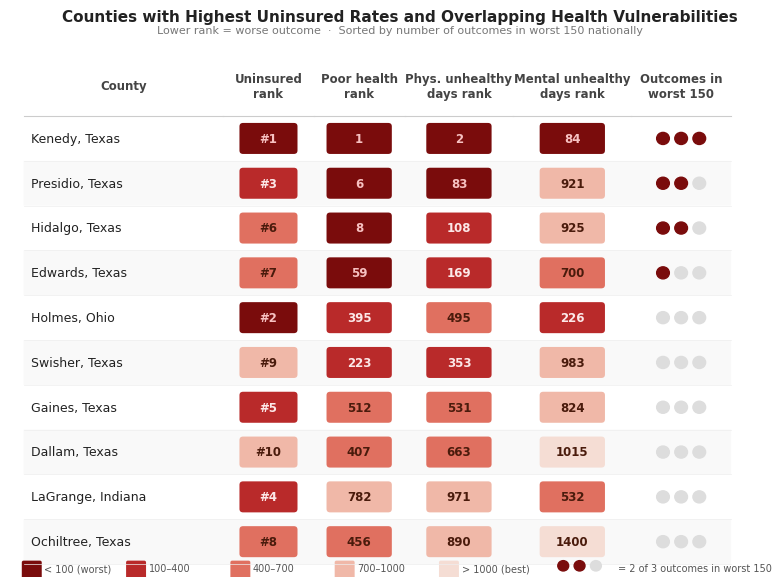

In [49]:


# --- your data (replace with heatmap_data) ---
# Expected columns: County_State, Uninsured Rank, Poor Health Rank,
#                   Phys Unhealthy Days Rank, Mental Unhealthy Days Rank

df = heatmap_data.copy()

# Sort by number of outcomes in worst 200, then by sum of ranks (lower = worse)
outcome_cols = ["Poor Health Rank", "Phys Unhealthy Days Rank", "Mental Unhealthy Days Rank"]
df["bad_count"] = df[outcome_cols].apply(lambda r: (r <= 150).sum(), axis=1)
df["rank_sum"]  = df[outcome_cols].sum(axis=1)
df = df.sort_values(["bad_count", "rank_sum"], ascending=[False, True]).reset_index(drop=True)

# --- color mapping ---
def rank_to_color(r, max_rank=3159):
    """Dark red for low (bad) ranks, light for high (good) ranks."""
    if r <= 100:  return "#7a0c0c", "#f7c1c1"   # bg, text
    if r <= 400:  return "#b92a2a", "#fce8e8"
    if r <= 700:  return "#e07060", "#4a1b0c"
    if r <= 1000: return "#f0b8a8", "#4a1b0c"
    return "#f5ddd4", "#4a1b0c"

def uninsured_to_color(r):
    if r <= 2:  return "#7a0c0c", "#f7c1c1"
    if r <= 5:  return "#b92a2a", "#fce8e8"
    if r <= 8:  return "#e07060", "#4a1b0c"
    return "#f0b8a8", "#4a1b0c"

# --- layout ---
n_rows = len(df)
col_labels  = ["County", "Uninsured\nrank", "Poor health\nrank", "Phys. unhealthy\ndays rank", "Mental unhealthy\ndays rank", "Outcomes in\nworst 150"]
col_widths  = [2.2, 1.0, 1.0, 1.2, 1.3, 1.1]   # relative widths
row_h       = 0.52
header_h    = 0.7
pad         = 0.15

total_w = sum(col_widths) + pad * 2
total_h = header_h + n_rows * row_h + pad * 2

fig, ax = plt.subplots(figsize=(total_w, total_h))
ax.set_xlim(0, total_w)
ax.set_ylim(0, total_h)
ax.axis("off")
fig.patch.set_facecolor("white")

# x positions for each column
x_starts = [pad]
for w in col_widths[:-1]:
    x_starts.append(x_starts[-1] + w)

def cell_cx(col_i):
    return x_starts[col_i] + col_widths[col_i] / 2

def row_cy(row_i):
    """y center for a data row (row 0 = top)."""
    return total_h - pad - header_h - row_i * row_h - row_h / 2

# --- draw header ---
header_y = total_h - pad - header_h
for ci, label in enumerate(col_labels):
    ax.text(cell_cx(ci), header_y + header_h / 2, label,
            ha="center", va="center", fontsize=8.5, fontweight="bold", color="#444")
    ax.plot([x_starts[ci], x_starts[ci] + col_widths[ci]],
            [header_y, header_y], color="#ccc", lw=0.8)

# --- draw data rows ---
for ri, row in df.iterrows():
    cy = row_cy(ri)

    # alternating row background
    if ri % 2 == 1:
        rect = FancyBboxPatch((pad, cy - row_h/2), total_w - pad*2, row_h,
                              boxstyle="round,pad=0", linewidth=0,
                              facecolor="#f9f9f9", zorder=0)
        ax.add_patch(rect)

    # county name (col 0)
    ax.text(x_starts[0] + 0.08, cy, row["County_State"],
            ha="left", va="center", fontsize=9, color="#222")

    # uninsured rank (col 1)
    ur = int(row["Uninsured Rank"])
    bg, fg = uninsured_to_color(ur)
    pill = FancyBboxPatch((cell_cx(1) - 0.28, cy - 0.14), 0.56, 0.28,
                          boxstyle="round,pad=0.04", linewidth=0, facecolor=bg)
    ax.add_patch(pill)
    ax.text(cell_cx(1), cy, f"#{ur}", ha="center", va="center",
            fontsize=8.5, fontweight="bold", color=fg)

    # outcome rank cells (cols 2–4)
    for ci, col in enumerate(outcome_cols, start=2):
        val = int(row[col])
        bg, fg = rank_to_color(val)
        pill = FancyBboxPatch((cell_cx(ci) - 0.32, cy - 0.14), 0.64, 0.28,
                              boxstyle="round,pad=0.04", linewidth=0, facecolor=bg)
        ax.add_patch(pill)
        ax.text(cell_cx(ci), cy, str(val), ha="center", va="center",
                fontsize=8.5, fontweight="bold", color=fg)

    # dot indicators (col 5)
    dot_r   = 0.07
    dot_gap = 0.2
    n_dots  = 3
    dot_xs  = [cell_cx(5) + (i - 1) * dot_gap for i in range(n_dots)]
    ranks   = [row[c] for c in outcome_cols]
    for dx, rv in zip(dot_xs, ranks):
        color = "#7a0c0c" if rv <= 150 else "#ddd"
        circ  = Circle((dx, cy), dot_r, color=color, zorder=3)
        ax.add_patch(circ)

    # row divider
    ax.plot([pad, total_w - pad], [cy - row_h/2, cy - row_h/2], color="#eee", lw=0.5)

# --- legend ---
legend_y = pad * 0.6
legend_items = [
    ("#7a0c0c", "< 100 (worst)"),
    ("#b92a2a", "100–400"),
    ("#e07060", "400–700"),
    ("#f0b8a8", "700–1000"),
    ("#f5ddd4", "> 1000 (best)"),
]
lx = pad
for bg, label in legend_items:
    sq = FancyBboxPatch((lx, legend_y - 0.1), 0.18, 0.18,
                         boxstyle="round,pad=0.02", linewidth=0, facecolor=bg)
    ax.add_patch(sq)
    ax.text(lx + 0.23, legend_y + 0.01, label, va="center", fontsize=7, color="#555")
    lx += 1.15

# dot legend
dot_lx = lx + 0.2
for i in range(3):
    c = Circle((dot_lx + i * 0.18, legend_y + 0.04), 0.06,
               color="#7a0c0c" if i < 2 else "#ddd", zorder=3)
    ax.add_patch(c)
ax.text(dot_lx + 0.6, legend_y + 0.01, "= 2 of 3 outcomes in worst 150",
        va="center", fontsize=7, color="#555")

# --- title ---
fig.text(0.5, 0.98, "Counties with Highest Uninsured Rates and Overlapping Health Vulnerabilities",
         ha="center", va="top", fontsize=11, fontweight="bold", color="#222")
fig.text(0.5, 0.955, "Lower rank = worse outcome  ·  Sorted by number of outcomes in worst 150 nationally",
         ha="center", va="top", fontsize=8, color="#777")

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.savefig("county_health_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()